In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

### Weights

In [3]:
import sys
sys.path.append('../')
from src import dataloader
from models.attention import Tokenizer, AccImgEmbed

In [7]:
data_loader_training, data_loader_validate, data_loader_test = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = False,
    data = 's2',
    exp_name = 'test'
    )

(13875, 36) | (8233, 36) | (12443, 36)


In [8]:
from collections import defaultdict
def process_dataloader(dataloader):
    cultivar_dict = defaultdict(list)  # Store masks for each cultivar type
    
    # Iterate over the dataloader
    for batch in dataloader:
        cultivar = batch['cultivar'][0]  # Extract cultivar type
        mask = batch['mask'][0].mean()  # Extract mask (label)
        
        # Append mask (label) values to the corresponding cultivar type
        cultivar_dict[cultivar].append(mask)
    
    return cultivar_dict

In [9]:
mean_label_dict = process_dataloader(data_loader_training)

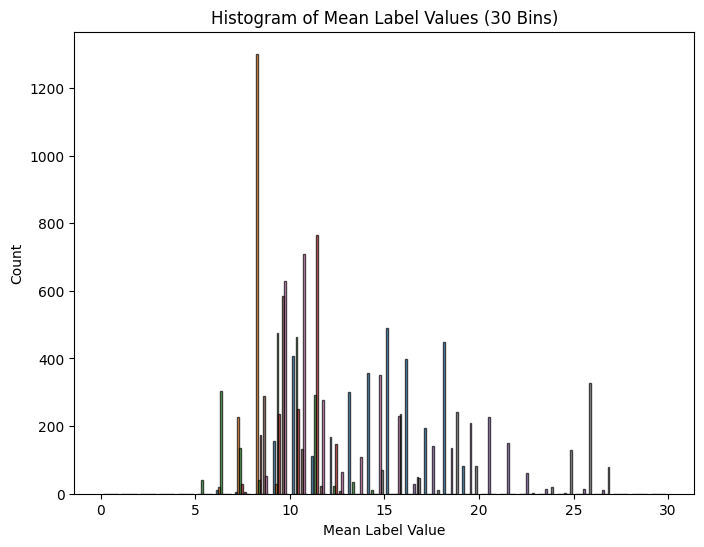

In [15]:
import matplotlib.pyplot as plt
import numpy as np


def plot_histogram(mean_label_dict):
    # Extract mean values from the dictionary
    mean_values = list(mean_label_dict.values())

    # Define bin edges: 30 bins between 0 and 30
    bins = np.linspace(0, 30, 31)

    # Set figure size to 8x6
    plt.figure(figsize=(8, 6))

    # Create histogram for the entire dataset
    plt.hist(mean_values, bins=bins, edgecolor='black', alpha=0.7)

    # Labeling the plot
    plt.title('Histogram of Mean Label Values (30 Bins)')
    plt.xlabel('Mean Label Value')
    plt.ylabel('Count')
    
    plt.show()

# Example usage
plot_histogram(mean_label_dict)


In [12]:
data_loader_training2, data_loader_validate2, data_loader_test2 = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = True,
    data = 's2',
    exp_name = 'test'
    )

(13875, 36) | (8233, 36) | (12443, 36)
resampling is True, The dataloader is processing cost-sensitive resampling!


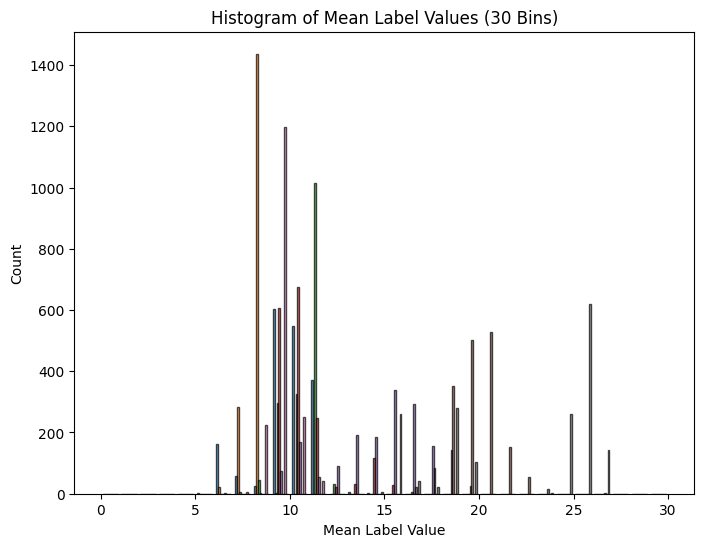

In [16]:
mean_label_dict2 = process_dataloader(data_loader_training2)
plot_histogram(mean_label_dict2)

In [17]:
data_loader_training3, data_loader_validate3, data_loader_test3 = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = True,
    data = 's2',
    exp_name = 'test'
    )

(13875, 36) | (8233, 36) | (12443, 36)
resampling is True, The dataloader is processing cost-sensitive resampling!


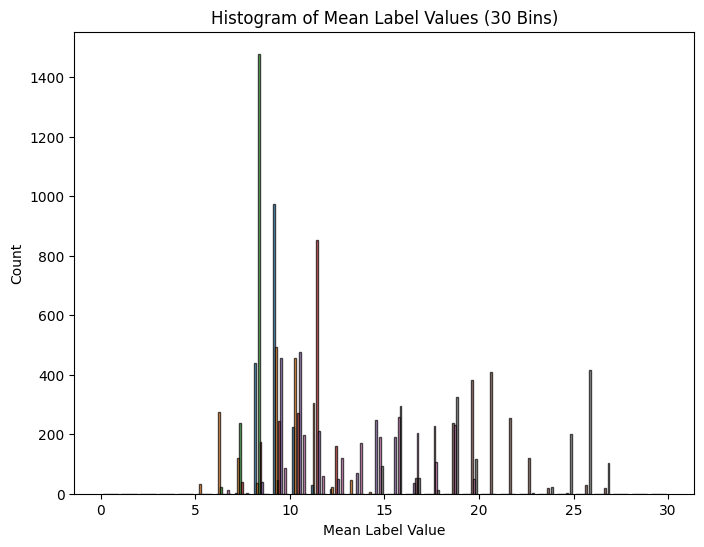

In [18]:
mean_label_dict3 = process_dataloader(data_loader_training3)
plot_histogram(mean_label_dict3)

In [22]:
data_loader_training4, data_loader_validate4, data_loader_test4 = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = True,
    data = 's2',
    exp_name = 'test'
    )

(13875, 36) | (8233, 36) | (12443, 36)
resampling is True, The dataloader is processing cost-sensitive resampling!


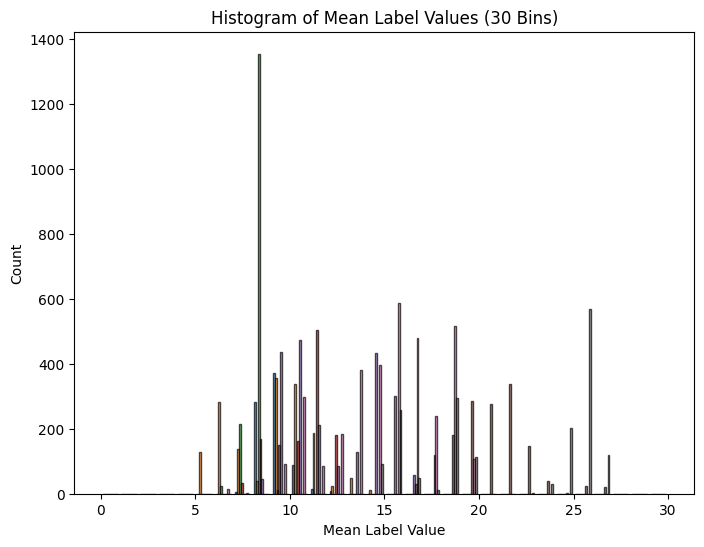

In [23]:
mean_label_dict4 = process_dataloader(data_loader_training4)
plot_histogram(mean_label_dict4)

### IMG

In [8]:
dataset = data_loader_training.dataset
index = 1000  
sample = dataset[index]

In [40]:
from models import configs
config = configs.Configs(
    img_size = 16, 
    patch_size = 8, 
    embed_dim = 768, 
    context_dim = 768,
    mlp_dim = 512, 
    pool = 'cls',
    in_channels = 2,
    out_channels = 1, 
    num_heads = 8, 
    num_layers = 6, 
    cond = False,
    multi_conv = False,
    attn_dropout = 0.1, 
    proj_dropout = 0.1, 
    drop_path = 0.0,
    post_norm = False, 
    vis = True, 
    tokenizer = 'ec',
    mask_modality = None
    ).call()

img_embeds_acc = AccImgEmbed(config, 15)#.to(device)
img_embeds_cnn = Tokenizer(n_input_channels = 2,
                    n_output_channels=768,
                    kernel_size=7,
                    stride=2,
                    padding=3,
                    pooling_kernel_size=3,
                    pooling_stride=2,
                    pooling_padding=1,
                    max_pool=True,
                    activation=nn.ReLU,
                    n_conv_layers=1,
                    conv_bias=False)#.to(device)

In [37]:
image = sample['image'][:4, ...]
image = torch.unsqueeze(image, dim  = 0)

In [38]:
acc_out = img_embeds_acc(image)
cnn_out = img_embeds_cnn(image)
print(acc_out.shape, cnn_out.shape)

torch.Size([1, 61, 768]) torch.Size([1, 240, 768])


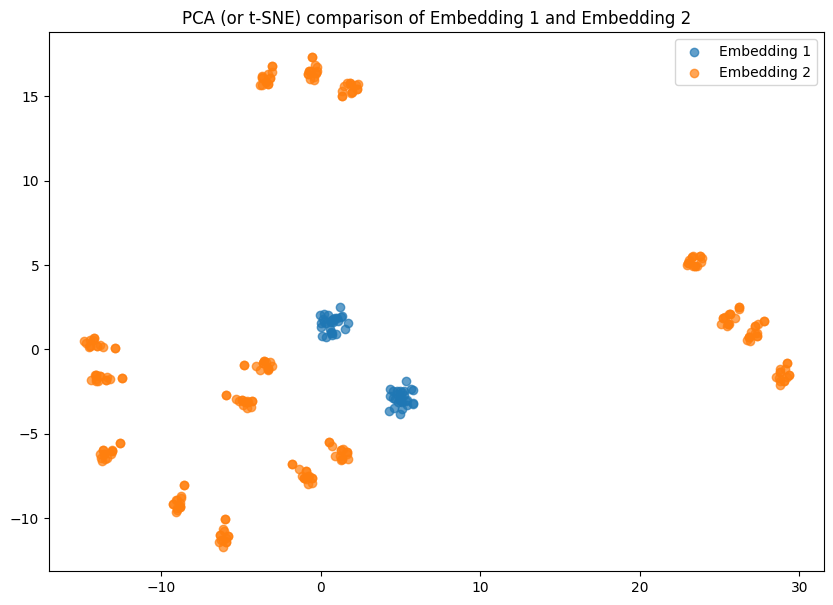

In [53]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


acc_embeds = acc_out[:, 1:, :].squeeze(0).detach().numpy()
cnn_embeds = cnn_out.squeeze(0).detach().numpy()  

# pca = PCA(n_components=2)

# reduced_acc_embeds = pca.fit_transform(acc_embeds)
# reduced_cnn_embeds = pca.fit_transform(cnn_embeds)

# Option 2: t-SNE (Uncomment if you want to use t-SNE instead of PCA)
tsne = TSNE(n_components=2, random_state=42)
reduced_acc_embeds = tsne.fit_transform(acc_embeds)
reduced_cnn_embeds = tsne.fit_transform(cnn_embeds)

# Plot the embeddings
plt.figure(figsize=(10, 7))
plt.scatter(reduced_acc_embeds[:, 0], reduced_acc_embeds[:, 1], label='Embedding 1', alpha=0.7)
plt.scatter(reduced_cnn_embeds[:, 0], reduced_cnn_embeds[:, 1], label='Embedding 2', alpha=0.7)

plt.title("PCA (or t-SNE) comparison of Embedding 1 and Embedding 2")
plt.legend()
plt.show()

In [41]:
image2 = sample['image'][4:, ...]
image2 = torch.unsqueeze(image2, dim  = 0)

In [42]:
acc_out = img_embeds_acc(image2)
cnn_out = img_embeds_cnn(image2)
print(acc_out.shape, cnn_out.shape)

torch.Size([1, 61, 768]) torch.Size([1, 240, 768])


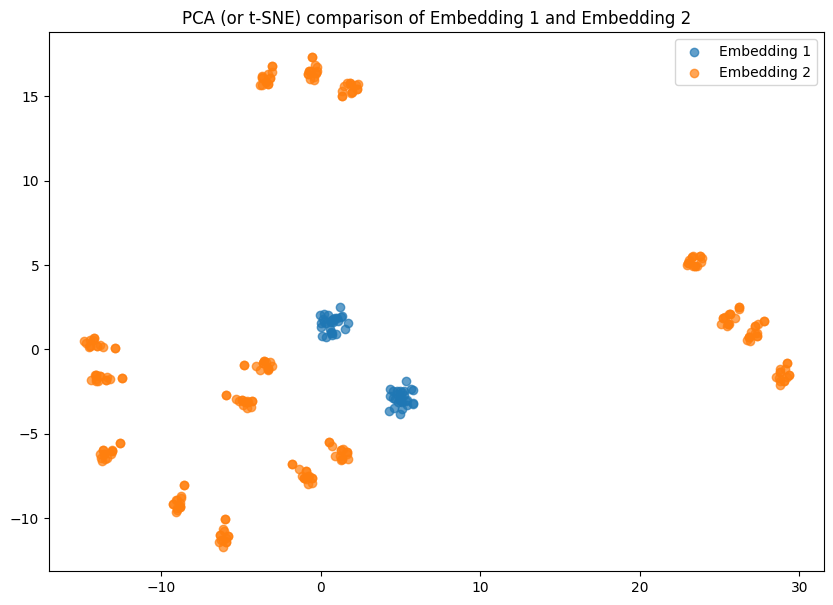

In [52]:
acc_embeds = acc_out[:, 1:, :].squeeze(0).detach().numpy()
cnn_embeds = cnn_out.squeeze(0).detach().numpy()  

pca = PCA(n_components=2)

# reduced_acc_embeds = pca.fit_transform(acc_embeds)
# reduced_cnn_embeds = pca.fit_transform(cnn_embeds)

# Option 2: t-SNE (Uncomment if you want to use t-SNE instead of PCA)
tsne = TSNE(n_components=2, random_state=42)
reduced_acc_embeds = tsne.fit_transform(acc_embeds)
reduced_cnn_embeds = tsne.fit_transform(cnn_embeds)

# Plot the embeddings
plt.figure(figsize=(10, 7))
plt.scatter(reduced_acc_embeds[:, 0], reduced_acc_embeds[:, 1], label='Embedding 1', alpha=0.7)
plt.scatter(reduced_cnn_embeds[:, 0], reduced_cnn_embeds[:, 1], label='Embedding 2', alpha=0.7)

plt.title("PCA (or t-SNE) comparison of Embedding 1 and Embedding 2")
plt.legend()
plt.show()

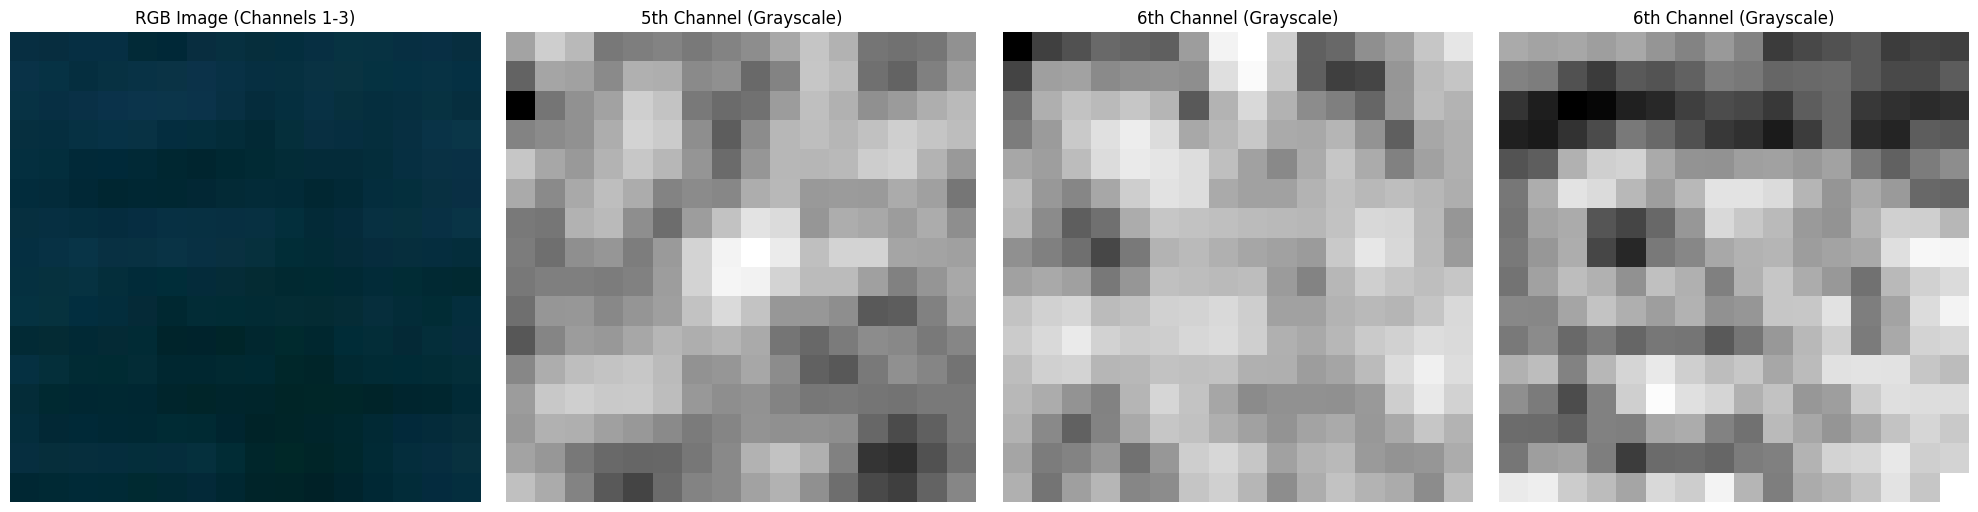

In [51]:
image = sample['image']
# Select one time series (for example, time series 0)
timeseries_idx = 13
selected_timeseries = image[..., timeseries_idx]  # Shape will be (6, height, width)

# Separate channels for plotting
rgb_channels = selected_timeseries[:3]       # First 3 channels for RGB
channel_5 = selected_timeseries[4]           # 5th channel
channel_6 = selected_timeseries[5]           # 6th channel

# Prepare RGB image by normalizing the values to [0, 1] for displaying
rgb_image = rgb_channels.permute(1, 2, 0).numpy()  # Rearrange to (height, width, 3)
# rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())  # Normalize

# Plotting
fig, ax = plt.subplots(1, 4, figsize=(20, 5))  # 1 row, 3 columns

# Subplot 1: RGB image
ax[0].imshow(rgb_image)
ax[0].set_title("RGB Image (Channels 1-3)")
ax[0].axis('off')  # Turn off the axis

# Subplot 2: 5th channel
ax[1].imshow(channel_5.numpy(), cmap='gray')
ax[1].set_title("5th Channel (Grayscale)")
ax[1].axis('off')  # Turn off the axis

# Subplot 3: 6th channel
ax[2].imshow(channel_6.numpy(), cmap='gray')
ax[2].set_title("6th Channel (Grayscale)")
ax[2].axis('off')  # Turn off the axis

# Subplot 3: 6th channel
ax[3].imshow(sample['mask'][0, :, :, 0].numpy(), cmap='gray')
ax[3].set_title("6th Channel (Grayscale)")
ax[3].axis('off')  # Turn off the axis
# Show the plot
plt.tight_layout()
plt.show()

### enhancement

In [5]:
import cv2
import numpy as np

def enhance_contrast(image, method='global_histogram'):
    """
    Enhance contrast of an image based on the specified method, outputting a new image.
    
    Args:
    - image (numpy.ndarray): Input image array with values normalized to 0-255 and shape (H, W, C).
    - method (str): Method used for contrast enhancement.
        - 'global_histogram': Global Histogram Equalization
        - 'ahe': Adaptive Histogram Equalization
        - 'clahe': Contrast Limited Adaptive Histogram Equalization
        - 'gamma': Gamma Correction
        - 'linear_stretch': Linear Stretching
        - 'log_transform': Logarithmic Transformation
        - 'exp_transform': Exponential Transformation
        - 'unsharp_mask': Unsharp Masking
        - 'wavelet': Wavelet Transform (simplified approach)
    
    Returns:
    - (numpy.ndarray): The new contrast enhanced image.
    """
    # Create a copy of the image to work on
    enhanced = np.copy(image)

    if method == 'global_histogram':
        # Global Histogram Equalization
        for i in range(enhanced.shape[2]):
            enhanced[:, :, i] = cv2.equalizeHist(enhanced[:, :, i].astype(np.uint8))
    
    elif method == 'ahe':
        # Adaptive Histogram Equalization
        ahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        for i in range(enhanced.shape[2]):
            enhanced[:, :, i] = ahe.apply(enhanced[:, :, i].astype(np.uint8))
    
    elif method == 'clahe':
        # CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        for i in range(enhanced.shape[2]):
            enhanced[:, :, i] = clahe.apply(enhanced[:, :, i].astype(np.uint8))
    
    elif method == 'gamma':
        # Gamma Correction
        gamma = 1.2  # Gamma < 1 darkens the image, Gamma > 1 brightens the image
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in range(256)]).astype("uint8")
        enhanced = cv2.LUT(enhanced.astype(np.uint8), table)
    
    elif method == 'linear_stretch':
        # Linear Stretching
        min_val = np.min(enhanced)
        max_val = np.max(enhanced)
        enhanced = 255 * (enhanced - min_val) / (max_val - min_val)
        enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)
    
    elif method == 'log_transform':
        # Logarithmic Transformation
        c = 255 / np.log(1 + np.max(enhanced))
        enhanced = c * np.log(1 + enhanced)
        enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)
    
    elif method == 'exp_transform':
        # Exponential Transformation
        c = 255 / (np.exp(np.max(enhanced)) - 1)
        enhanced = c * (np.exp(enhanced) - 1)
        enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)
    
    elif method == 'unsharp_mask':
        # Unsharp Masking
        gaussian = cv2.GaussianBlur(enhanced, (9, 9), 10.0)
        enhanced = cv2.addWeighted(enhanced, 1.5, gaussian, -0.5, 0, enhanced)
    
    elif method == 'wavelet':
        # Simplified Wavelet Transform Approach
        # Placeholder for wavelet transform
        pass
    
    return enhanced

# Example usage:
# img = cv2.imread('path_to_your_image.tif', -1) # Load an image
# img_enhanced = enhance_contrast(img, method='clahe') # Apply CLAHE


In [6]:
dataset = data_loader_training.dataset
index = 0  
sample = dataset[index]

In [7]:
img = sample['image'][:4, :, :, 13].detach().numpy()

In [ ]:
img_enhanced = enhance_contrast(img, method='exp_transform')
img_enhanced

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison(original, enhanced, title='Comparison'):
    """
    Plot the original and enhanced images side-by-side.

    Args:
    - original (numpy.ndarray): Original image array with shape (H, W, C).
    - enhanced (numpy.ndarray): Enhanced image array with shape (H, W, C).
    - title (str): Title for the plot.
    """
    # Assuming the images are in BGR format from OpenCV, convert to RGB for plotting
    # original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    # enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
    original = original.transpose(1, 2, 0)
    enhanced = enhanced.transpose(1, 2, 0)


    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enhanced / 255.)
    plt.title('Enhanced Image')
    plt.axis('off')

    plt.suptitle(title)
    plt.show()

# plot_comparison(img, img_enhanced, title='Original vs. CLAHE Enhanced Image')


In [11]:
def histogram_equalization(image):
    """
    Apply histogram equalization to each channel of the image, ensuring each channel is an 8-bit single-channel image.
    
    Args:
    - image (numpy.ndarray): Input image array with values normalized to 0-255 and shape (H, W, C).
    
    Returns:
    - (numpy.ndarray): The histogram equalized image.
    """
    # Assuming the image is loaded with multiple channels (e.g., RGB and NIR)
    if image.dtype != np.uint8:
        # Convert image to uint8 if not already
        image = np.clip(image, 0, 255).astype(np.uint8)

    # Split the image into its respective channels
    channels = cv2.split(image)
    
    # Apply histogram equalization to each channel
    eq_channels = [cv2.equalizeHist(channel) for channel in channels]
    
    # Merge the channels back together
    eq_image = cv2.merge(eq_channels)
    
    return eq_image


In [12]:
hist = histogram_equalization(img)

In [16]:
hist.shape

(4, 16, 16)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


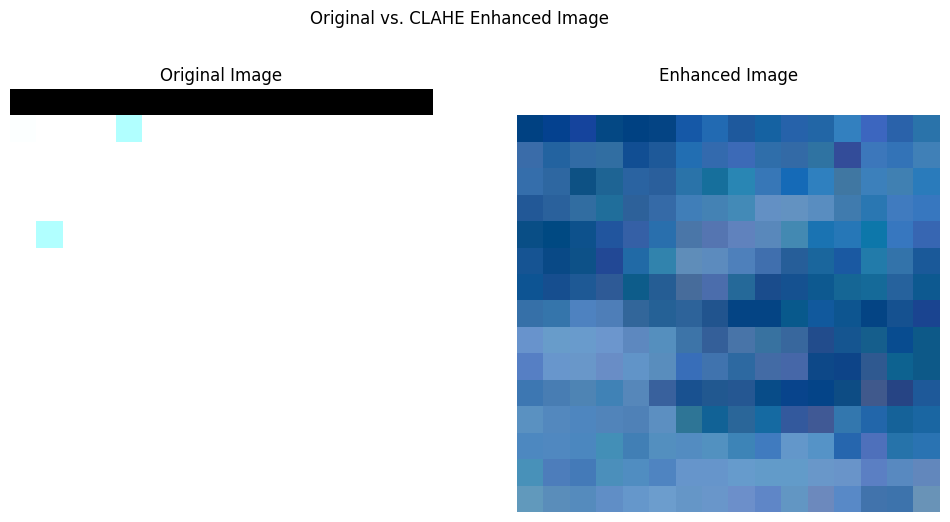

In [14]:
plot_comparison(img[:3], hist, title='Original vs. CLAHE Enhanced Image')